### Projeto 006 — Previsão do Preço de Acções com Python e Machine Learning

###### Vamos utilizar uma Rede Neural Artificial Recorrente denominada Long Short-Term Memory (LSTM) para prever o preço de fecho das ações de uma empresa (Apple Inc.), com base nos preços das ações registados nos 60 dias anteriores.

#### Importar as Bibliotecas e pacotes

In [15]:
!pip install --upgrade pip
!pip install --upgrade yfinance --q
!pip install tensorflow pandas-datareader matplotlib scikit-learn pandas numpy --q

  Using cached pip-26.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.2.1-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Tomane Asus\anaconda3\python.exe -m pip install --upgrade pip


In [16]:
import math
import numpy as np
import pandas as pd
import pandas_datareader as web
import matplotlib.pyplot as plt

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

plt.style.use("fivethirtyeight")

#### Vamos obter os dados das accoes da Yahoo desde (2014 ate 2025)

In [18]:
df = yf.download("AAPL", start="2014-01-01", end="2025-12-31", auto_adjust=False, progress=False, multi_level_index=False)
df

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2014-01-02,17.110126,19.754642,19.893929,19.715000,19.845715,234684800
2014-01-03,16.734293,19.320715,19.775000,19.301071,19.745001,392467600
2014-01-06,16.825544,19.426071,19.528570,19.057142,19.194643,412610800
2014-01-07,16.705217,19.287144,19.498571,19.211430,19.440001,317209200
2014-01-08,16.811001,19.409286,19.484285,19.238930,19.243214,258529600
...,...,...,...,...,...,...
2025-12-23,271.620667,272.359985,272.500000,269.559998,270.839996,29642000
2025-12-24,273.066711,273.809998,275.429993,272.200012,272.339996,17910600
2025-12-26,272.657837,273.399994,275.369995,272.859985,274.160004,21521800


#### Vamos visualizar graficamente o historico de fechamento dos precos

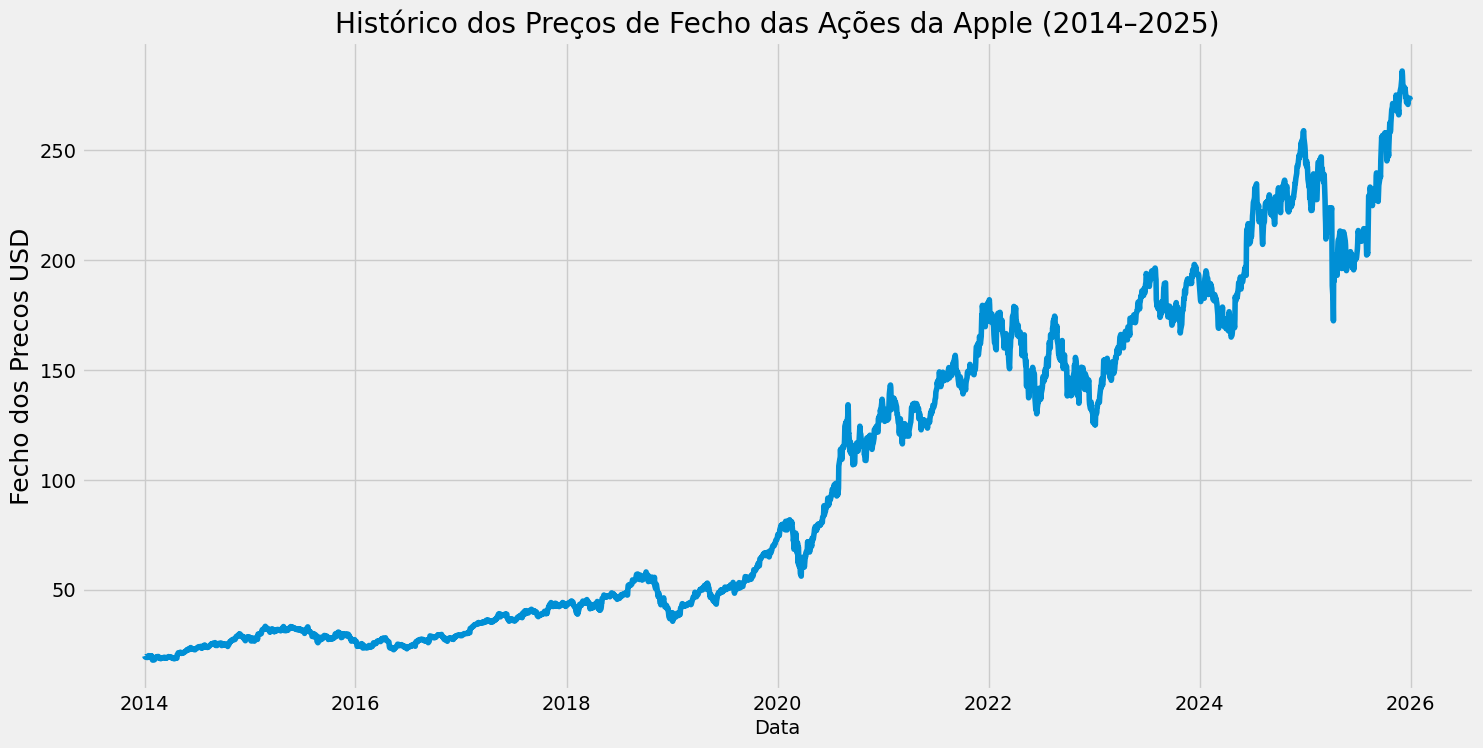

In [61]:
plt.figure(figsize=(16,8))
plt.title("Histórico dos Preços de Fecho das Ações da Apple (2014–2025)")
plt.plot(df["Close"])
plt.xlabel("Data", fontsize=14)
plt.ylabel("Fecho dos Precos USD", fontsize=18)
plt.show()

#### Interpretação do gráfico

O gráfico apresenta uma tendência geral de valorização das ações da Apple entre 2014 e 2025, apesar das várias oscilações e períodos de queda observados ao longo do tempo. A valorização tornou-se mais acentuada a partir de 2020, acompanhada também por maior volatilidade.

Por exemplo, uma ação comprada por aproximadamente 100 USD em 2021 poderia ter sido vendida por cerca de 200 USD em 2024, representando uma valorização aproximada de 100%, sem considerar dividendos, impostos, comissões e inflação.

Contudo, o desempenho histórico não garante resultados futuros. A tendência apresentada pelo gráfico, isoladamente, não é suficiente para concluir que comprar ações da Apple seria necessariamente um bom investimento.

Nota: Esta interpretação tem finalidade exclusivamente académica e não constitui aconselhamento financeiro.

#### Vamos criar um dataframe so com os dados de Close

In [25]:
dados = df.filter(["Close"])

# Converter o dataframe em uma numpy array
dataset = dados.values

#### Divisao dos dados para Treinamento dos Modelos

In [26]:
# Vamos dividir 80% dos dados para treino.

dados_treinamento = math.ceil( len(dataset) * .8)

In [27]:
dados_treinamento

2414

#### Normalizacao dos Dados

In [28]:
norm = MinMaxScaler(feature_range=(0,1))

dados_norm = norm.fit_transform(dataset)

dados_norm

array([[0.00710052],
       [0.00548344],
       [0.00587606],
       ...,
       [0.95233668],
       [0.95367832],
       [0.95114414]], shape=(3017, 1))

#### Criar dados de Treinamento

In [30]:
# Criar um conjunto de treino
# Criar conjunto de treinamento normalizado

dados_treino = dados_norm[0:dados_treinamento, :]

# Vamos dividir os dados
x_treino = []
y_treino = []

for i in range (60, len(dados_treino)):
    x_treino.append(dados_treino[i-60:i,0])
    y_treino.append(dados_treino[i,0])
    
    if i<=61:
        print(x_treino)
        print(y_treino)
        print()

[array([0.00710052, 0.00548344, 0.00587606, 0.00535833, 0.00581351,
       0.00488984, 0.00441337, 0.0047847 , 0.00620347, 0.0076635 ,
       0.00724958, 0.00544218, 0.00656016, 0.00688491, 0.00750645,
       0.00616088, 0.00675048, 0.00089439, 0.0001291 , 0.        ,
       0.00010914, 0.00023291, 0.00119917, 0.00170492, 0.00169428,
       0.00264855, 0.00388765, 0.00481531, 0.00480998, 0.00594261,
       0.00588404, 0.00615023, 0.00500297, 0.00417513, 0.00338988,
       0.00369599, 0.00296532, 0.00233845, 0.00371197, 0.00352165,
       0.00372395, 0.00418711, 0.00433618, 0.00412189, 0.00408064,
       0.00414452, 0.00483261, 0.00490182, 0.00410859, 0.00331535,
       0.00358819, 0.0042084 , 0.00418977, 0.00384905, 0.00440405,
       0.0052452 , 0.00601714, 0.00532372, 0.00501495, 0.00493509])]
[np.float64(0.00491912526498918)]

[array([0.00710052, 0.00548344, 0.00587606, 0.00535833, 0.00581351,
       0.00488984, 0.00441337, 0.0047847 , 0.00620347, 0.0076635 ,
       0.00724958, 0.00

#### Converter dados de treino para numpy pra garantir o preprocessanto dos dados

In [32]:
x_treino, y_treino = np.array(x_treino), np.array(y_treino)

#### Remodelar os dados

In [33]:
# Remodelar porque uma rede LSTM precisa que a entrada dos dados seja numa amostra tridimensional (numero de amostras, intervalo de tempo e numero de recursos)
# Uma vez que nosso conjunto de dados de x eh bidimensional.

x_treino.shape

(2354, 60)

In [35]:
x_treino = np.reshape(x_treino, (x_treino.shape[0], x_treino.shape[1], 1))
x_treino.shape

(2354, 60, 1)

#### Construcao da Arquitetura

In [45]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape = (x_treino.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\Tomane Asus\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Compilar o modelo

In [46]:
model.compile(optimizer='adam', loss='mean_squared_error')

#### Treinar a arquitetura

In [47]:
model.fit(x_treino, y_treino, batch_size=16, epochs=5)

Epoch 1/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0022
Epoch 2/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 2.1556e-04
Epoch 3/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 2.5481e-04
Epoch 4/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 2.0381e-04
Epoch 5/5
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.7624e-04


#### Criar conjunto de teste dos dados

In [48]:
dados_teste = dados_norm[dados_treinamento - 60: , :]

# Criar x teste e y teste
x_teste = []
y_teste = dataset[dados_treinamento:, :]

for i in range(60, len(dados_teste)):
    x_teste.append(dados_teste[i-60:i, 0])

#### Converter para uma matriz numpy

In [49]:
x_teste = np.array(x_teste)

#### Remodelar os dados pra permitir entrada 3D no LSTM

In [50]:
x_teste = np.reshape(x_teste, (x_teste.shape[0], x_teste.shape[1], 1))

#### Obter os precos obtidos pelos modelos

In [51]:
previsoes = model.predict(x_teste)  # Nota: Ao trazermos os dados das previsoes feitas pelo modelo, os dados vao estar normalizados de 0 a 1. 
#Entao temos que trazer os dados inversos para tomarem a originalidade do nosso banco de dados.

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [52]:
previsoes = norm.inverse_transform(previsoes)

#### Avaliacao do Modelo

In [53]:
# Obter o Quadrado Medio dos Erros
QME = np.sqrt( np.mean( previsoes - y_teste )**2 )
QME

np.float64(3.707598482198383)

### Visualizacao Grafica dos Dados

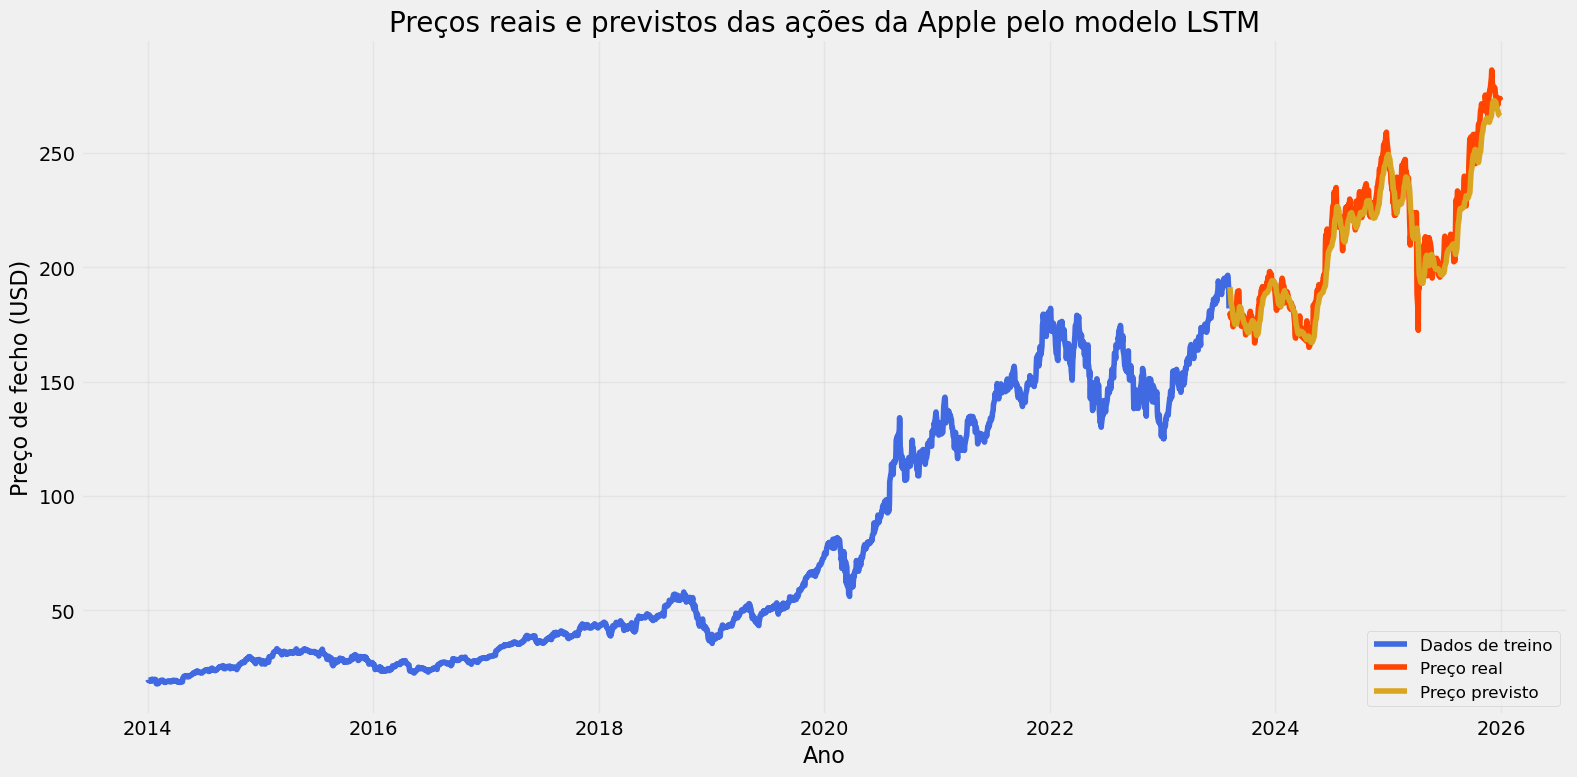

In [58]:
# Separar os dados de treino e validação
treino = dados.iloc[:dados_treinamento].copy()
validacao = dados.iloc[dados_treinamento:].copy()

# Adicionar as previsões ao conjunto de validação
validacao["Previsoes"] = np.asarray(previsoes).reshape(-1)

# Visualizar os resultados
plt.figure(figsize=(16, 8))
plt.plot(treino.index, treino["Close"], color="royalblue", label="Dados de treino")
plt.plot(validacao.index, validacao["Close"], color="orangered", label="Preço real")
plt.plot(validacao.index, validacao["Previsoes"], color="goldenrod", label="Preço previsto")

plt.title("Preços reais e previstos das ações da Apple pelo modelo LSTM", fontsize=20)
plt.xlabel("Ano", fontsize=16)
plt.ylabel("Preço de fecho (USD)", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretação
O modelo LSTM acompanhou de perto os preços reais das acções da Apple, indicando um bom desempenho predictivo. Contudo, as previsões foram mais suaves e apresentaram pequenas diferenças durante variações repentinas do mercado. O RMSE de 3,71 USD representa um erro relativamente baixo considerando a escala dos preços analisados.

### Vamos ver a tabela das previsoes

In [59]:
valid

,Close,previsoes
Date,,
2023-08-07,178.850006,191.296082
2023-08-08,179.800003,189.679199
2023-08-09,178.190002,187.847397
2023-08-10,177.970001,185.886414
2023-08-11,177.789993,183.972122
...,...,...
2025-12-23,272.359985,267.587921
2025-12-24,273.809998,266.915985
2025-12-26,273.399994,266.482574


### Outras metricas

In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

real = validacao["Close"].to_numpy().reshape(-1)
previsto = validacao["Previsoes"].to_numpy().reshape(-1)

mae = mean_absolute_error(real, previsto)
mse = mean_squared_error(real, previsto)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(real, previsto) * 100
r2 = r2_score(real, previsto)

# Acurácia da direção dos preços
direcao_real = np.sign(np.diff(real))
direcao_prevista = np.sign(np.diff(previsto))
acuracia_direcional = np.mean(
    direcao_real == direcao_prevista
) * 100

print(f"MAE: {mae:.2f} USD")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} USD")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")
print(f"Acurácia direcional: {acuracia_direcional:.2f}%")

MAE: 6.18 USD
MSE: 62.22
RMSE: 7.89 USD
MAPE: 2.84%
R²: 0.9304
Acurácia direcional: 51.16%


In [63]:
rmse_lstm = np.sqrt(
    mean_squared_error(real[1:], previsto[1:])
)

rmse_baseline = np.sqrt(
    mean_squared_error(real[1:], real[:-1])
)

print(f"RMSE da LSTM: {rmse_lstm:.2f} USD")
print(f"RMSE do baseline: {rmse_baseline:.2f} USD")

RMSE da LSTM: 7.88 USD
RMSE do baseline: 3.47 USD


In [64]:
direcao_real = np.sign(real[1:] - real[:-1])
direcao_prevista = np.sign(previsto[1:] - real[:-1])

acuracia_direcional = np.mean(
    direcao_real == direcao_prevista
) * 100

print(f"Acurácia direcional: {acuracia_direcional:.2f}%")

Acurácia direcional: 47.51%
